# Sales Forecasting
The objective of this notebook is to forecast future monthly sales using historical retail transaction data. Forecasting helps businesses estimate future demand, optimize inventory, and support strategic planning.

In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

In [ ]:
#Load Dataset
df = pd.read_csv("Retail_Feature_Engineered.csv")

In [ ]:
#Convert Date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
#Monthly Sales
monthly_sales = (
    df.groupby(pd.Grouper(key="InvoiceDate", freq="ME"))["TotalAmount"]
      .sum()
      .reset_index()
)

In [16]:
monthly_sales.head()

,InvoiceDate,TotalAmount
0,2009-12-31,683504.010
1,2010-01-31,555802.672
2,2010-02-28,504558.956
3,2010-03-31,696978.471
4,2010-04-30,591982.002


In [ ]:
#Prophet Format
forecast_df = monthly_sales.rename(
    columns={
        "InvoiceDate": "ds",
        "TotalAmount": "y"
    }
)

In [17]:
forecast_df.head()

,ds,y
0,2009-12-31,683504.010
1,2010-01-31,555802.672
2,2010-02-28,504558.956
3,2010-03-31,696978.471
4,2010-04-30,591982.002


In [ ]:
#Train Model
model = Prophet()

In [ ]:
model.fit(forecast_df)

20:58:58 - cmdstanpy - INFO - Chain [1] start processing
20:58:59 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
#Future Dates
future = model.make_future_dataframe(
    periods=12,
    freq="ME"
)

In [ ]:
#Forecast
forecast = model.predict(future)

In [12]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
20,2011-08-31,9.307905e+05,671153.399995,1.162665e+06
21,2011-09-30,9.487086e+05,702445.399955,1.217839e+06
22,2011-10-31,9.672239e+05,700548.632411,1.234524e+06
23,2011-11-30,9.851419e+05,735279.907666,1.235391e+06
24,2011-12-31,1.003657e+06,747096.357782,1.257097e+06


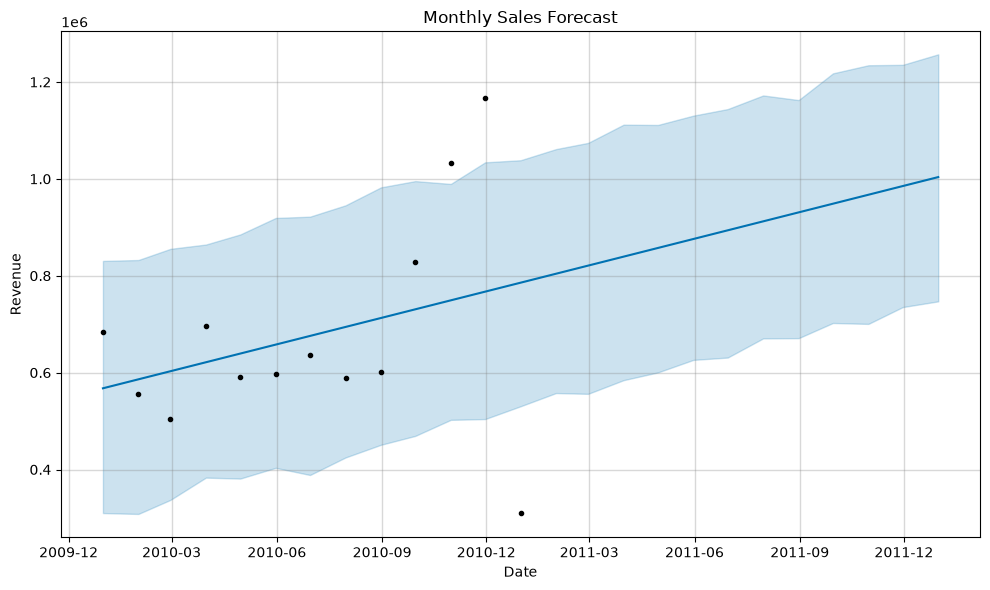

In [ ]:
#Forecast Graph
fig = model.plot(forecast)

plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

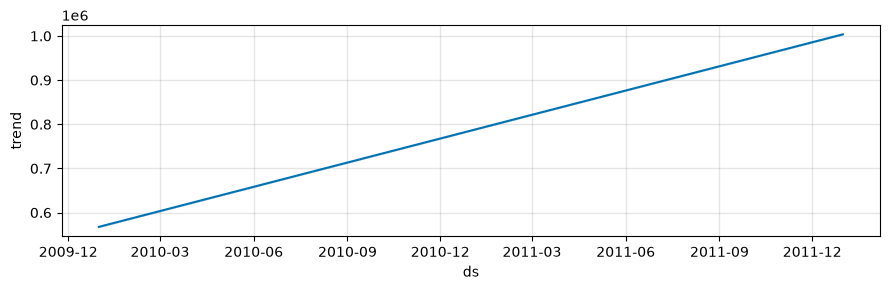

In [ ]:
#Forecast Components
model.plot_components(forecast)
plt.show()

In [ ]:
#Save Forecast
forecast.to_csv("Sales_Forecast.csv", index=False)

## Business Insight

- Historical sales were used to forecast future monthly revenue.
- Forecasting helps businesses estimate future demand and improve inventory planning.
- The predicted trend can support budgeting and marketing strategies.

## Conclusion

A time-series forecasting model was developed using Prophet to predict future monthly sales. The generated forecasts can support demand planning, inventory optimization, and strategic business decisions.
